# 1.

# Predicting the price of an insurance, given other information

## Objectives:
Given information about age, sex, bmi, childrens, smoking data, and region, observe correlation with the charges of the patient.

Find the characteristic, which has greatest linear dependence with the target data.

To visualize dependance between different data, to eaze the process of understanding correlation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tabulate import tabulate

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor


df = pd.read_csv('/content/drive/MyDrive/data/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## DATA information

### Source
Dataset was taken from the Kaggle (https://www.kaggle.com/datasets/mirichoi0218/insurance?resource=download), available to anyone. It's the dataset of information about pt, and the price of an insurance

### Columns

age: age of a patient *(integer)*

sex: insurance contractor gender *(female/male)*

bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height,
objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9 *((floating point))*

children: Number of children covered by health insurance / Number of dependents *(integer)*

smoker: Smoking (*yes/no)*

region: the beneficiary's residential area in the US, *(northeast/southeast/southwest/northwest)*

charges: Individual medical costs billed by health insurance *(floating point)*



# 2.
I've already downloaded the dataset.

In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.drop_duplicates(inplace=True) # inplace=true just updates the dataset itself, instead of creating a copy
print(df.shape)
df

(1337, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Checking if there are outliers in the dataset

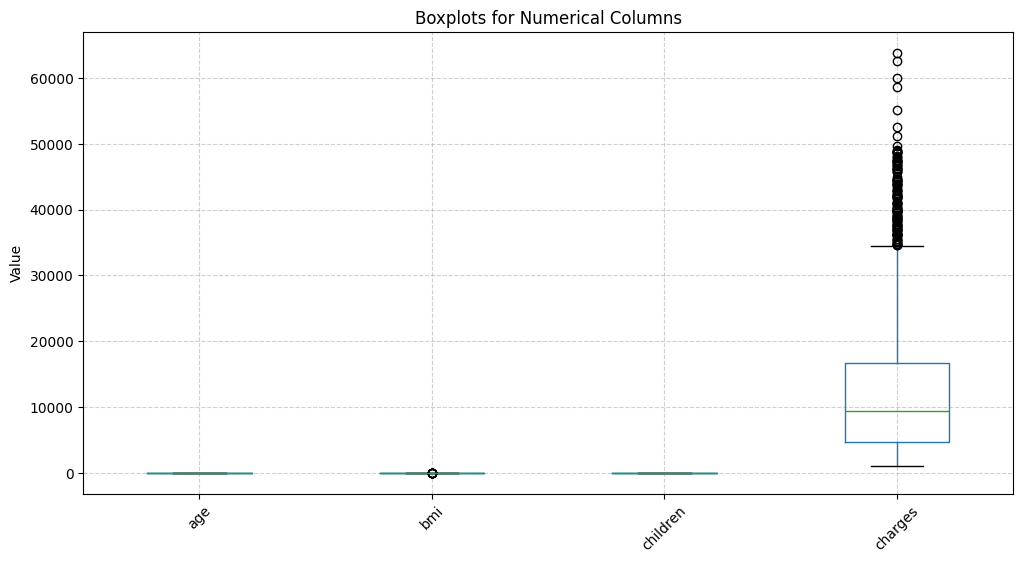

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(12, 6))
df[num_cols].boxplot()
plt.title("Boxplots for Numerical Columns")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

outliers_dict = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if not outliers.empty:
        outliers_dict[col] = outliers
        print(f"\n🔹 Outliers in column '{col}': {len(outliers)} found")
        display(outliers[[col] + ['sex', 'region']])
    else:
        print(f"\n✅ No outliers detected in '{col}'")


✅ No outliers detected in 'age'

🔹 Outliers in column 'bmi': 9 found


,bmi,sex,region
116,49.06,male,southeast
286,48.07,female,northeast
401,47.52,male,southeast
543,47.41,female,southeast
847,50.38,male,southeast
860,47.60,female,southwest
1047,52.58,male,southeast
1088,47.74,male,southeast
1317,53.13,male,southeast



✅ No outliers detected in 'children'

🔹 Outliers in column 'charges': 139 found


,charges,sex,region
14,39611.75770,male,southeast
19,36837.46700,male,southwest
23,37701.87680,female,northeast
29,38711.00000,male,southwest
30,35585.57600,male,southwest
...,...,...,...
1300,62592.87309,male,southeast
1301,46718.16325,male,northwest
1303,37829.72420,male,southwest
1313,36397.57600,female,southwest


In [ ]:
# Getting rid of an outliers
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bmi = Q1 - 1.5 * IQR
upper_bmi = Q3 + 1.5 * IQR
df = df[(df['bmi'] >= lower_bmi) & (df['bmi'] <= upper_bmi)]

df = df.reset_index(drop=True)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1323,50,male,30.970,3,no,northwest,10600.54830
1324,18,female,31.920,0,no,northeast,2205.98080
1325,18,female,36.850,0,no,southeast,1629.83350
1326,21,female,25.800,0,no,southwest,2007.94500


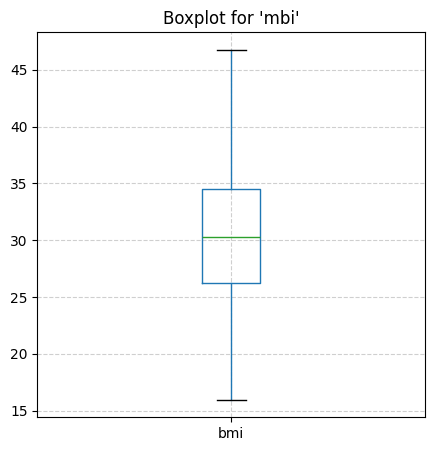

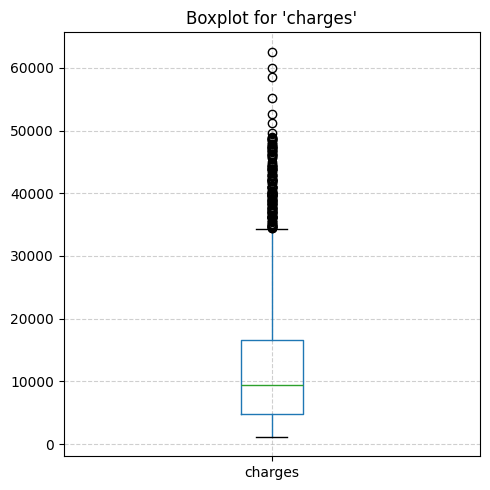

In [ ]:
plt.figure(figsize=(5, 5))
df[['bmi']].boxplot()
plt.title("Boxplot for 'mbi'")
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.6)

plt.figure(figsize=(5, 5))
df[['charges']].boxplot()
plt.title("Boxplot for 'charges'")
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

There was 9 outliers detected in the bmi column, and 139 in the Charges column.
I got rid of them, so they won't make a mess with the model we want to create

And I also visualised it

### Changing data types

In [ ]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1328 non-null   int64  
 1   sex       1328 non-null   object 
 2   bmi       1328 non-null   float64
 3   children  1328 non-null   int64  
 4   smoker    1328 non-null   int64  
 5   region    1328 non-null   object 
 6   charges   1328 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 72.8+ KB


In [ ]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1328 non-null   int64  
 1   sex       1328 non-null   int64  
 2   bmi       1328 non-null   float64
 3   children  1328 non-null   int64  
 4   smoker    1328 non-null   int64  
 5   region    1328 non-null   object 
 6   charges   1328 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 72.8+ KB


In [ ]:
df['region'] = df['region'].map({'northeast': 0, 'southeast': 1, 'southwest': 2, 'northwest': 3})
# northeast/southeast/southwest/northwest
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1328 non-null   int64  
 1   sex       1328 non-null   int64  
 2   bmi       1328 non-null   float64
 3   children  1328 non-null   int64  
 4   smoker    1328 non-null   int64  
 5   region    1328 non-null   int64  
 6   charges   1328 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 72.8 KB


Data types for sex, smoker data, and regions were changed, to make it able to machine work with it

### Statistics

In [ ]:
print(df['age'].describe(), '\n\n', df['bmi'].describe(), '\n\n', df['children'].describe(), '\n\n', df['charges'].describe())

count    1328.000000
mean       39.219127
std        14.042170
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64 

 count    1328.000000
mean       30.537308
std         5.922176
min        15.960000
25%        26.220000
50%        30.300000
75%        34.488750
max        46.750000
Name: bmi, dtype: float64 

 count    1328.000000
mean        1.097139
std         1.208008
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64 

 count     1328.000000
mean     13221.047810
std      11997.547468
min       1121.873900
25%       4744.325050
50%       9369.615750
75%      16604.302645
max      62592.873090
Name: charges, dtype: float64


# 3.

## Visualisation


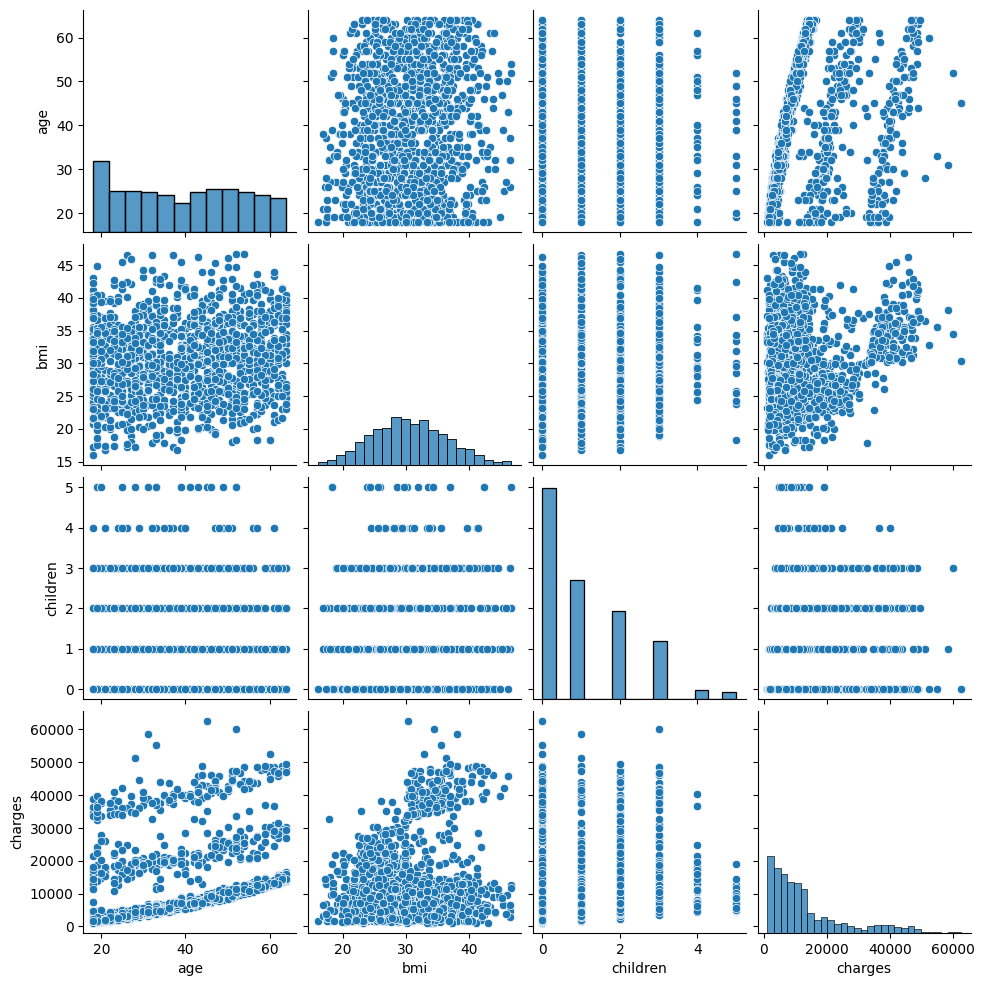

In [ ]:
sns.pairplot(df[['age', 'bmi', 'children', 'charges']])

### Histograms

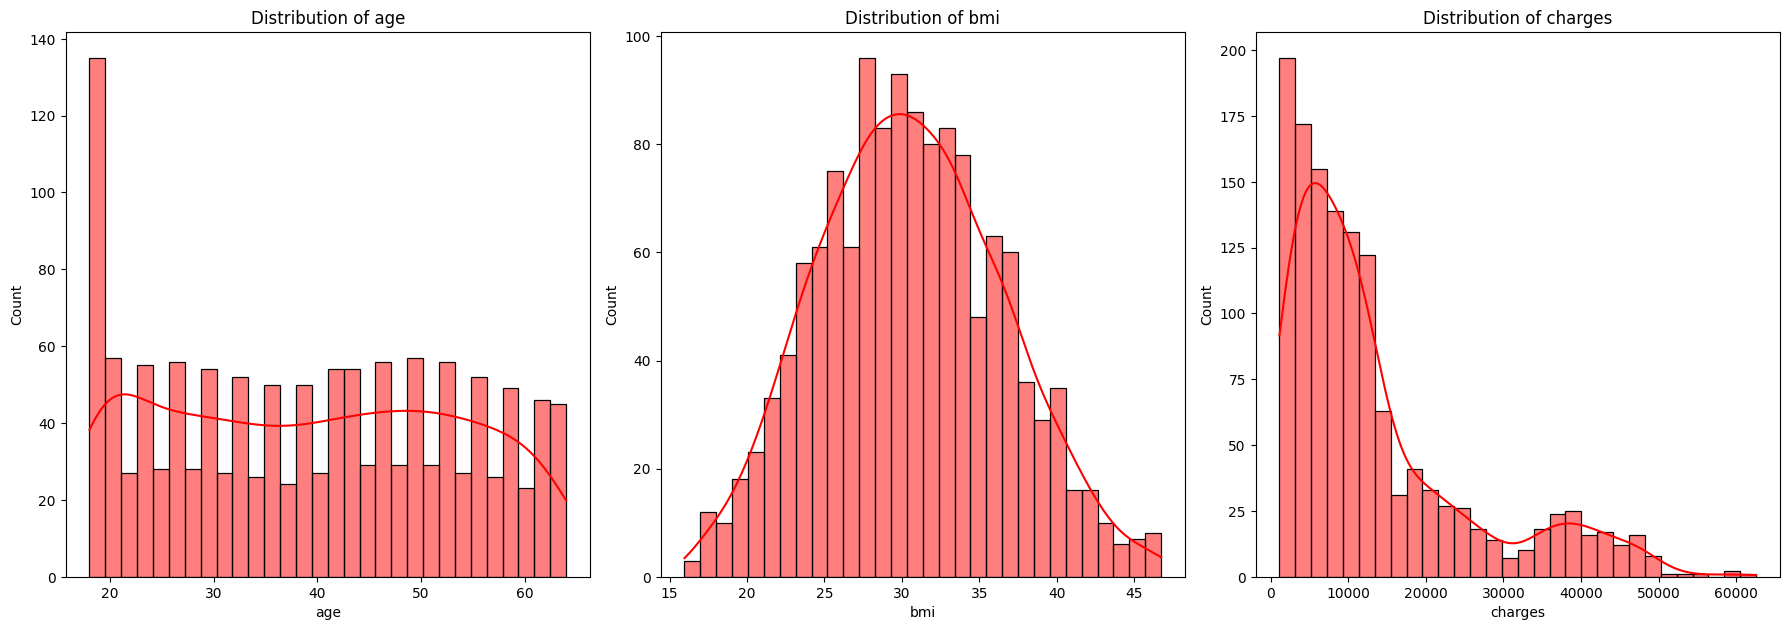

In [ ]:
num_cols = ['age', 'bmi', 'charges']

plt.figure(figsize=(18, 12))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30, color='red')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

From these graphs we can see
1. There is a really big spike at the younger people, probably there is a law implemented, requiring young people to apply to insurance
2. Other than that spike, ages are uniformly distributed
3. Bmi of a sample in a dataset is distributed normally, as in a poplution
4. Amount of charges is decaying, as we go higher and higher: There are less people paying more

### Scatterplots

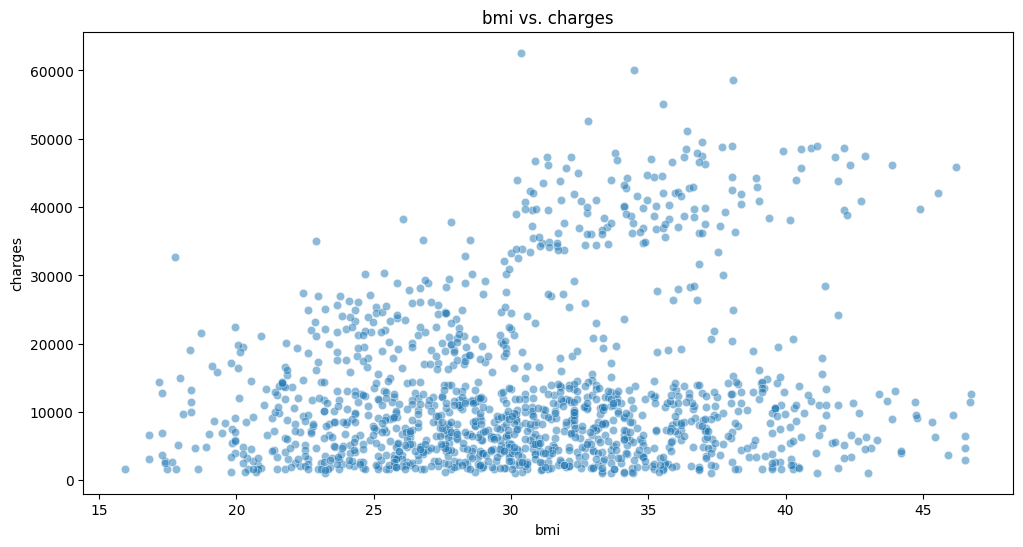

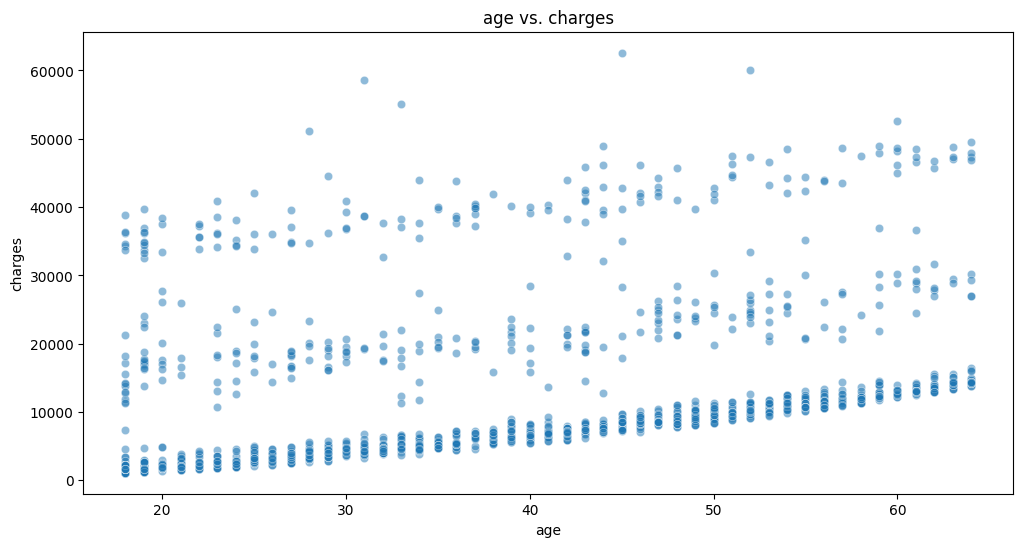

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='bmi', y='charges', data=df, alpha=0.5)
plt.title('bmi vs. charges')
plt.xlabel('bmi')
plt.ylabel('charges')

plt.figure(figsize=(12, 6))
sns.scatterplot(x='age', y='charges', data=df, alpha=0.5)
plt.title('age vs. charges')
plt.xlabel('age')
plt.ylabel('charges')

plt.show()

1. It seems to be, there is no correlation between bmi, and charges
2. However there is a little positive (one up, other up) correlation between age and charges: older people pay more

### Boxplots

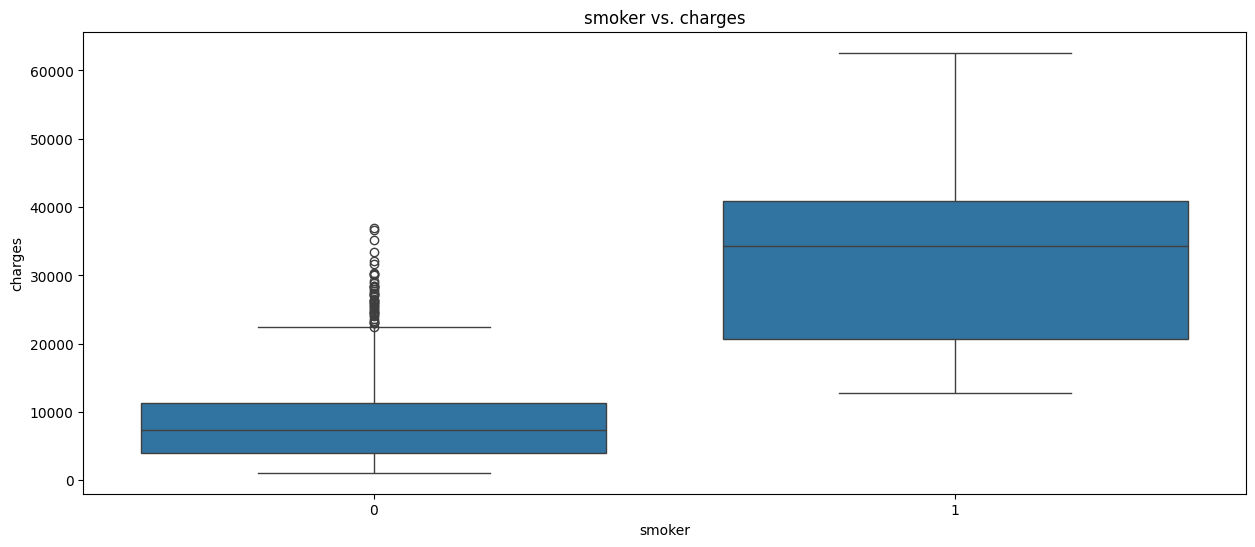

In [ ]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('smoker vs. charges')
plt.xlabel('smoker')
plt.ylabel('charges')
plt.show()

From those boxplots we can see, that there is a big difference in charges, depending if patient smokes, or not

# 4.

## Correlation matrix

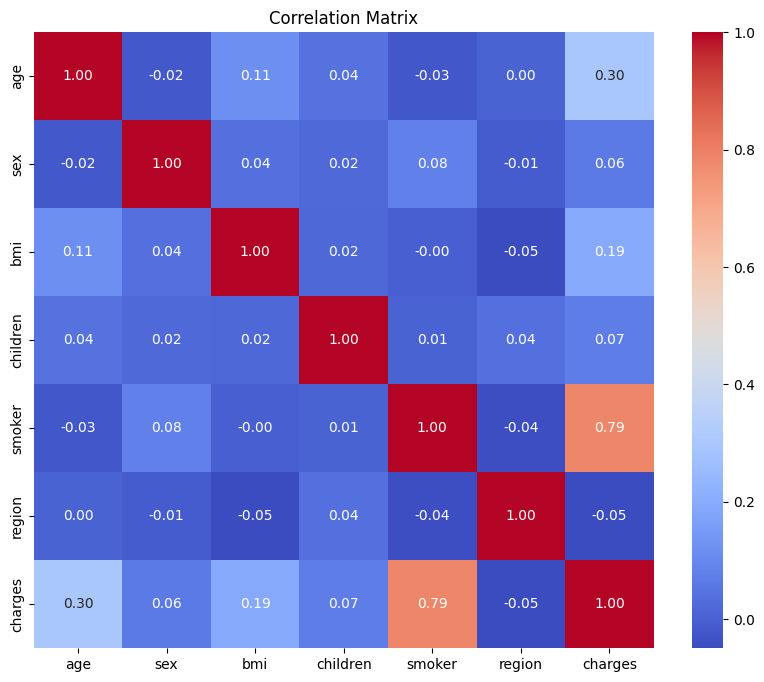

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10, 8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## Covariance matrix

In [ ]:
num_df = df[["age", "bmi", "children", "charges"]]

cov_matrix = num_df.cov()
print(cov_matrix)

                   age           bmi     children       charges
age         197.182543      9.545560     0.714192  5.076333e+04
bmi           9.545560     35.072173     0.124237  1.373217e+04
children      0.714192      0.124237     1.459283  1.001840e+03
charges   50763.328639  13732.167848  1001.840395  1.439411e+08


| Variable Pair    | Covariance | Interpretation                      |
| ---------------- | ---------- | ----------------------------------- |
| age–charges      | +44,586    | charges go up with age              |
| bmi–charges      | –2,361     | slight & meaningless negative trend |
| children–charges | +741       | very weak positive trend            |
| age–bmi          | +10        | weak co-movement                    |
| bmi–children     | –0.07      | essentially no relationship         |


The correlation matrix shows that the strongest predictor of medical charges is smoking, with a correlation of 0.60, indicating a strong positive relationship. Age is the second most important variable (0.44), showing that charges increase as individuals get older. Other variables such as BMI, sex, region, and number of children show only very weak correlations with charges.

The covariance matrix provides a similar picture. The covariance between age and charges is strongly positive (44,586), meaning that as age increases, insurance costs also increase. BMI and charges have a small negative covariance (–2,361), although the relationship is very weak. The number of children and charges have a small positive covariance (741), also indicating a weak effect.

Overall, both matrices confirm that smoking and age are the primary contributors to higher medical charges, while other variables have minimal linear impact.

# 5.
## T-test
I will be doing T-test on this dataset, comparing means (on charges) of two independent groups (smokers vs. non-smokers)

We will be doing Welch's T-test, since there might be a difference of variances between two groups, and it is more reliable when the two samples have unequal variances and possibly unequal sample sizes.

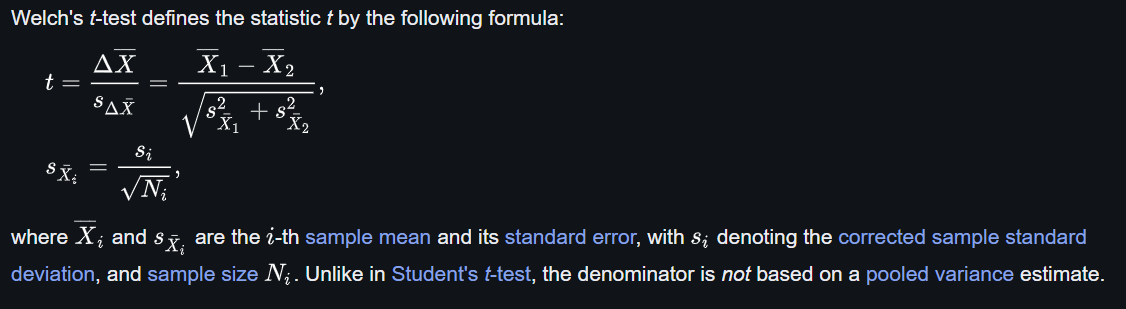

### Hypothesis:
Null Hypothesis ($H_0$): There is no difference in average charges between smokers and non-smokers.

Alternative Hypothesis (1$H_1$): There is a difference in average charges.

In [ ]:
smokers = df[df['smoker'] == 1]['charges']

non_smokers = df[df['smoker'] == 0]['charges']

t_stat, p_value = stats.ttest_ind(smokers, non_smokers, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Reject Null Hypothesis: There is a significant difference in charges.")
else:
    print("Fail to Reject Null Hypothesis: No significant difference found.")

T-statistic: 32.673134220128
P-value: 2.493601295238723e-102
Reject Null Hypothesis: There is a significant difference in charges.


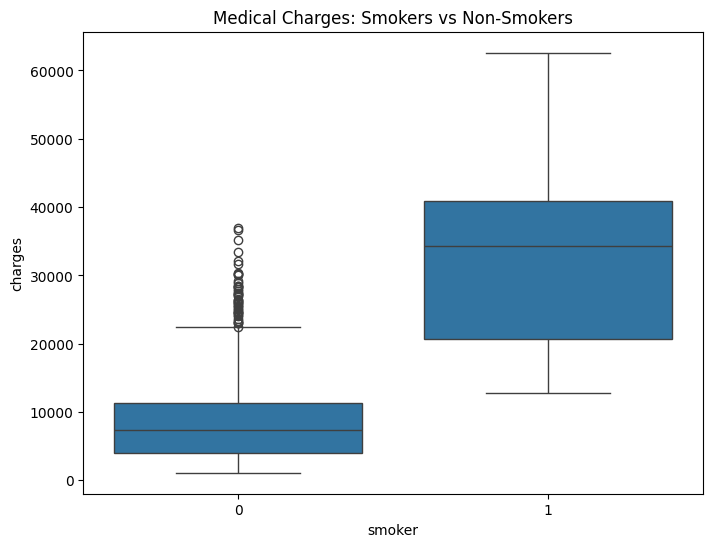

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Medical Charges: Smokers vs Non-Smokers')
plt.show()

## ANOVA-test

There are 4 different groups in a region column, which is why we will use ANOVA test, to evaluate if means are different

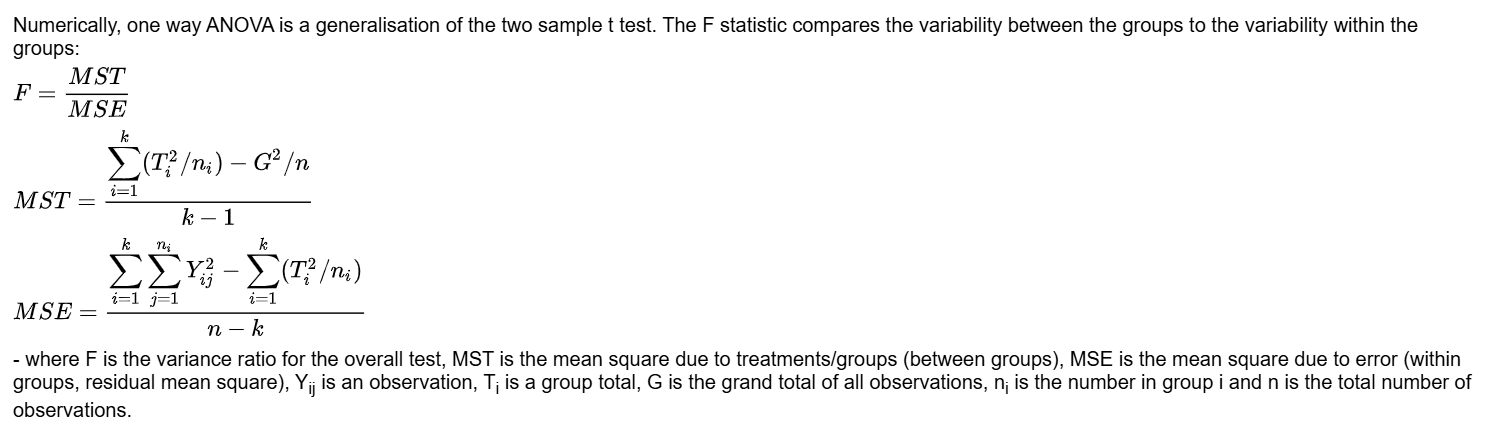

### Hypothesis
Null Hypothesis ($H_0$): The mean charges are the same across all four regions ($\mu_{sw} = \mu_{se} = \mu_{nw} = \mu_{ne}$).

Alternative Hypothesis ($H_1$): At least one region has a different mean charge.

In [ ]:
groups = [df[df['region'] == r]['charges'] for r in df['region'].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print(f"F-Statistic: {f_stat}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("Reject Null Hypothesis: At least one region has different charges.")
else:
    print("Fail to Reject Null: No significant difference between regions.")

F-Statistic: 2.8434181416869686
P-Value: 0.03663203181078598
Reject Null Hypothesis: At least one region has different charges.


## Chi-Square test

I used Chi-Square Test of Independence on region and smoker columns.

This test checks if the distribution of smokers is random across regions, or if a specific region has a disproportionately high or low number of smokers.

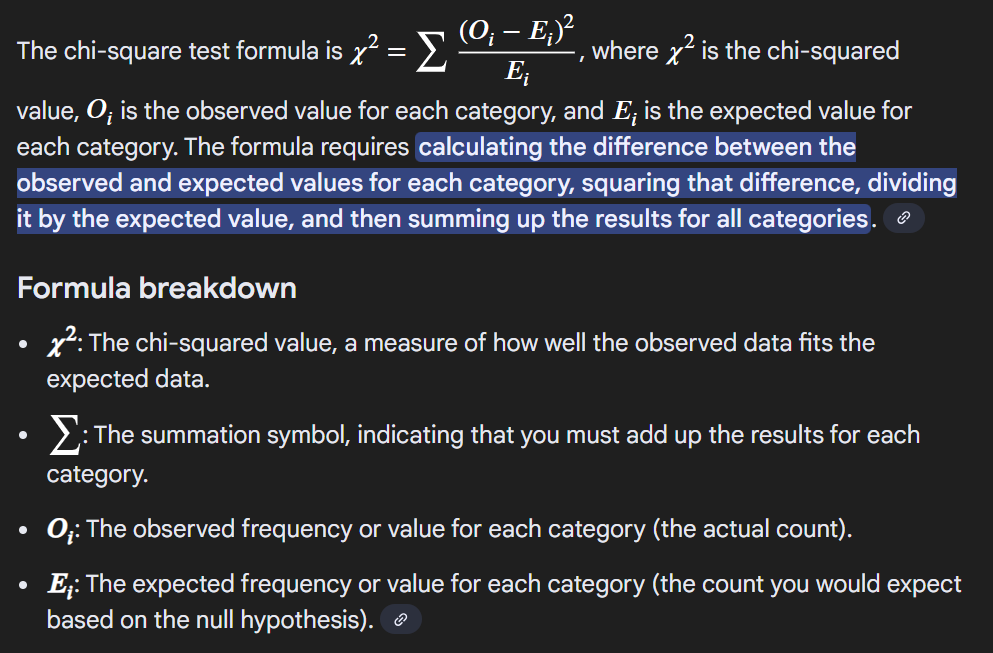

### Hypothesis

Null Hypothesis ($H_0$): There is no association between region and smoking status (they are independent).

Alternative Hypothesis ($H_1$): There is an association (they are dependent).

In [ ]:
contingency_table = pd.crosstab(df['region'], df['smoker'])

print("--- Contingency Table ---")
print(contingency_table)


chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2}")
print(f"P-value: {p}")

alpha = 0.05
if p < alpha:
    print("Reject Null Hypothesis: There IS a relationship between Region and Smoking.")
else:
    print("Fail to Reject Null: Region and Smoking appear to be independent.")

--- Contingency Table ---
smoker    0   1
region         
0       256  67
1       268  89
2       267  57
3       266  58

Chi-Square Statistic: 7.351435650261864
P-value: 0.06150112622827299
Fail to Reject Null: Region and Smoking appear to be independent.


# 6.

## Shapiro-Wilk test on the bmi

I used Shapiro-Wilk test on the bmi to check if the distribution of the bmi in the given dataset is normal. Bmi is a quantity ditrbuted normally, so we won't be able to work with data, if bmi in the dataset is not normal.

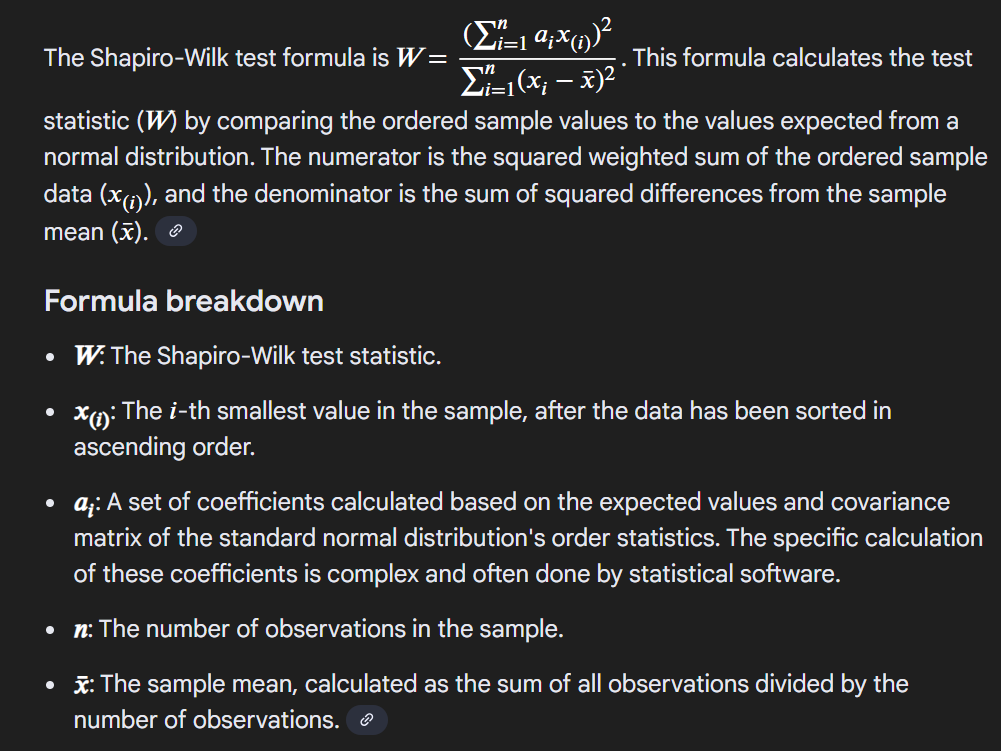

### Hypothesis

Null Hypothesis ($H_0$): The data is normally distributed.

Alternative Hypothesis ($H_1$): The data is not normally distributed

In [ ]:
stat, p_value = stats.shapiro(df['bmi'])

print(f"Shapiro-Wilk Statistic: {stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value > alpha:
    print("Fail to reject Null: Data looks Gaussian (Normal).")
else:
    print("Reject Null: Data does NOT look Gaussian (Not Normal).")

Shapiro-Wilk Statistic: 0.9951
P-Value: 0.0003
Reject Null: Data does NOT look Gaussian (Not Normal).


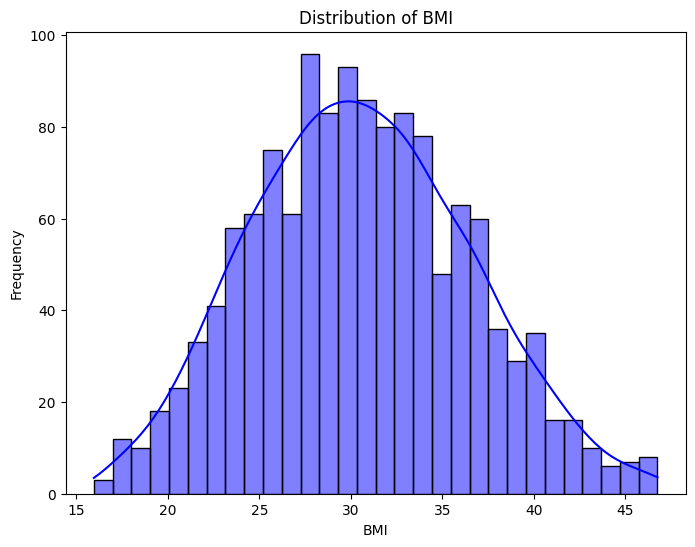

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['bmi'], kde=True, bins=30, color='blue')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

Since the size of a dataset is small, we won't take the result of a test as the right one, and will trust the graph, which looks bell-curved enough, to say, that it is normal distribution

## The Mann-Whitney U Test: charges between male/female
The Mann-Whitney U Test (also called the Wilcoxon Rank-Sum Test) compares the distributions of two independent groups without assuming a bell curve.
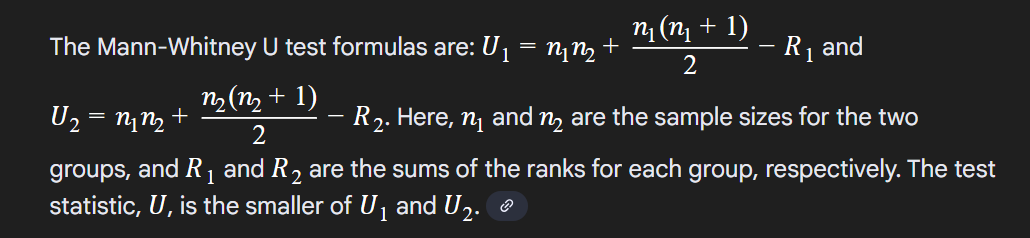

### Hypothesis
Null Hypothesis ($H_0$): The distribution of charges for males and females is the same.

Alternative Hypothesis ($H_1$): The distributions are different (e.g., one gender tends to have higher charges).

In [ ]:
male_charges = df[df['sex'] == 1]['charges']
female_charges = df[df['sex'] == 0]['charges']

u_stat, p_value = stats.mannwhitneyu(male_charges, female_charges, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_stat}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Reject Null Hypothesis: There is a significant difference in charges between males and females.")
else:
    print("Fail to Reject Null: No significant difference found between genders.")

Mann-Whitney U statistic: 224121.0
P-value: 0.5979413618988858
Fail to Reject Null: No significant difference found between genders.


# 7

Starting to build the models

In [ ]:
X = df.drop("charges", axis=1)
y = df["charges"]

#X is the independent variables for the models
#Y is the charges, thus - dependent variable

Our target value is the "charges"

In our code, the X value (independent variable) will be the all columns, other than charges. And by using predictive models we will try to find the dependent value Y, which is charges of pts

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


#splitted with 75/25 ratio
#explanation given below

In [ ]:
results = []

#function, which will be used, to calculate the adjusted r2 for each of the models
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

## Linear regression

In [ ]:
linreg = LinearRegression().fit(X_train, y_train)

y_pred = linreg.predict(X_test)

name = "Linear Regression"
r2 = r2_score(y_test, y_pred)
adj_r2 = adjusted_r2(r2, len(y_test), X_train.shape[1])
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(name, r2, adj_r2, rmse, mae)

results.append([name, r2, adj_r2, rmse, mae])

Linear Regression 0.769921480676857 0.766399870687217 5916.372623002789 4104.565966032045


In [ ]:
if isinstance(X, pd.DataFrame):
    coef_df = pd.DataFrame(list(zip(X.columns, linreg.coef_)), columns=['Feature', 'Coefficient'])
    print("\nCoefficients DataFrame:")
    print(coef_df)


Coefficients DataFrame:
    Feature   Coefficient
0       age    257.149975
1       sex      3.138374
2       bmi    318.556570
3  children    567.973175
4    smoker  23263.504187
5    region    -74.570470


### Interpretation of the coefficients:

From the list of coefficients we can see, that the most influential variable is the "smoker" data of the patient. And indeed, if pt is smoking, he has a lot more chance of getting different kind of health problems, meaning the insurance company would pay more for the pt. So, it is not a surprise, that they ask more from the pt

other important variables are bmi, and age. But they are almost ignorable, compared to smoker value

## Decision tree

In [ ]:
dectree = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)

y_pred = dectree.predict(X_test)

name = "Decision Tree"
r2 = r2_score(y_test, y_pred)
adj_r2 = adjusted_r2(r2, len(y_test), X_train.shape[1])
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(name, r2, adj_r2, rmse, mae)

results.append([name, r2, adj_r2, rmse, mae])

Decision Tree 0.665570598808833 0.6604517814436621 7132.958667761001 3470.5278817293233


## Random Forest

In [ ]:
ranfor = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)

y_pred = ranfor.predict(X_test)

name = "Random Forest"
r2 = r2_score(y_test, y_pred)
adj_r2 = adjusted_r2(r2, len(y_test), X_train.shape[1])
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(name, r2, adj_r2, rmse, mae)

results.append([name, r2, adj_r2, rmse, mae])

Random Forest 0.8417471118242547 0.839324873739932 4906.74291754256 2690.9943954166934


## Gradient Boosting

In [ ]:
grad = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)

y_pred = grad.predict(X_test)

name = "Gradient Boosting"
r2 = r2_score(y_test, y_pred)
adj_r2 = adjusted_r2(r2, len(y_test), X_train.shape[1])
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(name, r2, adj_r2, rmse, mae)

results.append([name, r2, adj_r2, rmse, mae])

Gradient Boosting 0.8653163610103931 0.863254876740144 4526.62901513769 2546.1939881614635


In [ ]:
df_results = pd.DataFrame(
    results,
    columns=["Model", "R²", "Adjusted R²", "RMSE", "MAE"]
)

df_results.sort_values(by="R²", ascending=False)


,Model,R²,Adjusted R²,RMSE,MAE
3,Gradient Boosting,0.865316,0.863255,4526.629015,2546.193988
2,Random Forest,0.841747,0.839325,4906.742918,2690.994395
0,Linear Regression,0.769921,0.766400,5916.372623,4104.565966
1,Decision Tree,0.665571,0.660452,7132.958668,3470.527882


In [ ]:
print(tabulate(df_results, headers="keys", tablefmt="github", floatfmt=".4f"))


|    | Model             |     R² |   Adjusted R² |      RMSE |       MAE |
|----|-------------------|--------|---------------|-----------|-----------|
|  0 | Linear Regression | 0.7699 |        0.7664 | 5916.3726 | 4104.5660 |
|  1 | Decision Tree     | 0.6656 |        0.6605 | 7132.9587 | 3470.5279 |
|  2 | Random Forest     | 0.8417 |        0.8393 | 4906.7429 | 2690.9944 |
|  3 | Gradient Boosting | 0.8653 |        0.8633 | 4526.6290 | 2546.1940 |


## SO, I've tested couple of different divisions for test and studying ratios, and here is the tables, for each one of different divisions

###for 0.3

3	Gradient Boosting	0.865316	0.863255	4526.629015	2546.193988

2	Random Forest	0.841747	0.839325	4906.742918	2690.994395

0	Linear Regression	0.769921	0.766400	5916.372623	4104.565966

1	Decision Tree	0.665571	0.660452	7132.958668	3470.527882




###for 0.25

3	Gradient Boosting	0.854819	0.852139	4748.854736	2626.715793

2	Random Forest	0.825566	0.822346	5205.339720	2827.978716

0	Linear Regression	0.762257	0.757868	6076.974497	4127.133367

1	Decision Tree	0.669529	0.663428	7164.736434	3493.840317




###for 0.2

3	Gradient Boosting	0.841547	0.837876	4693.051931	2588.393726

2	Random Forest	0.812163	0.807812	5109.706543	2839.582770

0	Linear Regression	0.748522	0.742696	5912.287550	4055.873423

1	Decision Tree	0.622397	0.613649	7244.747815	3327.759960

## Comparing different ratios

###Comparing 0.30 vs 0.25
Change in R2 (0.30 → 0.25): The R2 score only drops slightly (approx. 0.009).

Change in RMSE (0.30 → 0.25): The error increases slightly (approx. 85 units).

Conclusion: Moving from a 70/30 split to a 75/25 split causes minimal degradation in performance (a small R2 drop), suggesting that a 75% training set is large enough to capture the necessary patterns.

###  Comparing 0.25 vs 0.20
Change in R2 (0.25 → 0.20): The R2 score drops significantly (approx. 0.051).

Change in RMSE (0.25 → 0.20): The error increases significantly (approx. 139 units).

Conclusion: Moving from a 75/25 split to an 80/20 split causes a noticeable drop in performance (a larger R2 drop). This suggests that a 20% test set is likely too small to accurately represent the true population, leading to an overly optimistic evaluation of the model's true performance.


## The best model
 The Gradient Boosting Regressor was chosen as the final model because it provided the highest R² score and lowest RMSE after hyperparameter tuning. It successfully captures the complex, non-linear jumps in medical costs associated with smoking and high BMI, which the Linear Regression model failed to account for (evidenced by its lower R² of ~0.58).

## Tuning the Gradient Boosting method

In [ ]:
# here is the original result

grad42 = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)

y_pred = grad42.predict(X_test)

name = "Gradient Boosting"
r2 = r2_score(y_test, y_pred)
adj_r2 = adjusted_r2(r2, len(y_test), X_train.shape[1])
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("random_state=42", name, r2, adj_r2, rmse, mae)


random_state=42 Gradient Boosting 0.8653163610103931 0.863254876740144 4526.62901513769 2546.1939881614635


In [ ]:
#here i've tried to see, what will happen, if I will change the random state for the regressor

grad50 = GradientBoostingRegressor(random_state=50).fit(X_train, y_train)

y_pred = grad50.predict(X_test)

name = "Gradient Boosting"
r2 = r2_score(y_test, y_pred)
adj_r2 = adjusted_r2(r2, len(y_test), X_train.shape[1])
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("random_state=50",name, r2, adj_r2, rmse, mae)



random_state=50 Gradient Boosting 0.8651082529242426 0.8630435833261443 4530.124853579542 2552.347058727074


So, the amount of error increases, if we increase the random state, so I've tried to decrease it

In [ ]:
# decreasing

grad40 = GradientBoostingRegressor(random_state=40).fit(X_train, y_train)

y_pred = grad40.predict(X_test)

name = "Gradient Boosting"
r2 = r2_score(y_test, y_pred)
adj_r2 = adjusted_r2(r2, len(y_test), X_train.shape[1])
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("random_state=40",name, r2, adj_r2, rmse, mae)



random_state=40 Gradient Boosting 0.8653199159948681 0.8632584861376467 4526.569274391957 2543.1939205762646


So, the best random state is the 42

## Here is the code, for finding the best Gradient boosting hyperparameters

In [ ]:

gbr = GradientBoostingRegressor()

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    gbr,
    param_distributions=param_dist,
    n_iter=100,               # number of combinations to test
    scoring='r2',
    cv=5,                    # 5-fold cross-validation
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'subsample': 0.6, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.05}
Best CV R²: 0.8504405833113822


## By running that cell, we got the best hyperparameters, which are
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.01}


In [ ]:
final_gb_model = GradientBoostingRegressor(
    subsample=1,
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=2,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
)

final_gb_model.fit(X_train, y_train)

y_pred_final = final_gb_model.predict(X_test)

final_r2 = r2_score(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print("--- Final Tuned Gradient Boosting Results ---")
print(f"R2 Score: {final_r2:.4f}")
print(f"RMSE: {final_rmse:.2f}")

--- Final Tuned Gradient Boosting Results ---
R2 Score: 0.8739
RMSE: 4380.01


# 8.


## Statistical Findings:
### Smokers pay significantly more:
The T-test performed in the hypothesis testing section yielded a P-value of $\approx 0$, leading to the rejection of the null hypothesis. This statistically confirms that smoking status is the most significant driver of insurance charges.

### Age and BMI:
Correlation analysis showed a positive relationship between age/BMI and charges. However, the pairplots revealed that the impact of BMI is drastic specifically for smokers (the "obesity-smoking" interaction), creating a separate cluster of high-cost patients.

### Model Performance:
The Linear Regression model underperformed (R² $\approx 0.58$) because it assumes a constant additive effect of variables. Medical costs often scale exponentially or have threshold effects (e.g., costs skyrocket only if you are both a smoker and have high BMI), which the Tree-based models (Random Forest, Gradient Boosting) captured much better.

## Limitations:
### Variables:
We are limited to only a few variables. We lack medical history, pre-existing conditions, or plan type (deductible size), which are massive factors in real-world pricing.
### Size:
Dataset given has the small amount of data to succesfully use the output model

# 9.

## Key Findings:
### Smoking is the #1 Cost Factor:
Being a smoker essentially adds a massive fixed cost to insurance premiums, regardless of other factors.

### The "Double Whammy":
High BMI alone increases costs moderately, but High BMI + Smoking results in the highest charges in the dataset.

### Predictability:
Medical charges are highly predictable ($R^2 > 0.85$ with tuned models) using just basic demographic data (Age, BMI, Smoking), suggesting that insurers rely heavily on these simple risk factors.

## Recommendations:
### For Individuals:
he most actionable way to reduce medical insurance costs is smoking cessation. Maintaining a healthy BMI is secondary but increasingly critical for smokers.
### For Insurers:
The Gradient Boosting model should be deployed for pricing estimations as it handles the non-linear risk profiles of high-risk clients better than traditional linear actuarial tables.